# Задача

Реализовать класс `MyBinaryLogisticRegression` для работы с логистической регрессией. Обеспечить возможность использования `l1`, `l2` и `l1l2` регуляризации и реализовать слудующие методы решения оптимизационной задачи:

*   Градиентный спуск
*   Стохастический градиентный спуск
*   Метод Ньютона

Обосновать применимость/не применимость того или иного метода оптимизации в случае использованного типа регуляризации.



In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score

class MyBinaryLogisticRegression:
    def __init__(
        self,
        regularization=None,
        weight_calc="gd",
        lambda_1=0.0,
        lambda_2=0.0,
        learning_rate=0.1,
        max_iter=2000,
        tol=1e-6,
        batch_size=32,
        random_state=42,
    ):
        if regularization not in [None, "l1", "l2", "l1l2"]:
            raise TypeError(f"Некорректная regularization={regularization}")
        if weight_calc not in ["gd", "sgd", "newton"]:
            raise TypeError(f"Некорректная weight_calc={weight_calc}")
        if weight_calc == "newton" and regularization in ["l1", "l1l2"]:
            raise TypeError("Метод Ньютона нельзя использовать с L1/L1L2 (недифференцируемость)")

        self.regularization = regularization
        self.weight_calc = weight_calc
        self.lambda_1 = float(lambda_1)
        self.lambda_2 = float(lambda_2)
        self.learning_rate = float(learning_rate)
        self.max_iter = int(max_iter)
        self.tol = float(tol)
        self.batch_size = int(batch_size)
        self.random_state = int(random_state)

        self.coefs_ = None
        self.feature_names_in_ = None

    @staticmethod
    def _sigmoid(z):
        z = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z))

    def _prepare_X(self, X, fit=False):
        if isinstance(X, pd.DataFrame):
            if fit:
                self.feature_names_in_ = list(X.columns)
            Xv = X.values.astype(float)
        else:
            Xv = np.asarray(X, dtype=float)

        ones = np.ones((Xv.shape[0], 1), dtype=float)
        return np.hstack([ones, Xv])

    def _loss_grad_hess(self, Xb, y, w):
        n = Xb.shape[0]
        p = self._sigmoid(Xb @ w)

        eps = 1e-12
        loss = -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))

        grad = (Xb.T @ (p - y)) / n
        r = p * (1 - p)
        H = (Xb.T * r) @ Xb / n

        if self.regularization in ["l1", "l1l2"]:
            loss += self.lambda_1 * np.sum(np.abs(w[1:]))
            grad[1:] += self.lambda_1 * np.sign(w[1:])

        if self.regularization in ["l2", "l1l2"]:
            loss += 0.5 * self.lambda_2 * np.sum(w[1:] ** 2)
            grad[1:] += self.lambda_2 * w[1:]
            H[1:, 1:] += self.lambda_2 * np.eye(H.shape[0] - 1)

        return loss, grad, H

    def fit(self, X: pd.DataFrame, y):
        Xb = self._prepare_X(X, fit=True)
        yv = np.asarray(y, dtype=float).reshape(-1)

        rng = np.random.default_rng(self.random_state)
        w = rng.uniform(-0.01, 0.01, size=Xb.shape[1])

        if self.weight_calc == "gd":
            for _ in range(self.max_iter):
                _, grad, _ = self._loss_grad_hess(Xb, yv, w)
                w_new = w - self.learning_rate * grad
                if np.linalg.norm(w_new - w) < self.tol:
                    w = w_new
                    break
                w = w_new

        elif self.weight_calc == "sgd":
            n = Xb.shape[0]
            for _ in range(self.max_iter):
                idx = rng.permutation(n)
                Xs, ys = Xb[idx], yv[idx]

                w_old = w.copy()
                for start in range(0, n, self.batch_size):
                    end = start + self.batch_size
                    _, grad, _ = self._loss_grad_hess(Xs[start:end], ys[start:end], w)
                    w = w - self.learning_rate * grad

                if np.linalg.norm(w - w_old) < self.tol:
                    break

        else:
            for _ in range(self.max_iter):
                _, grad, H = self._loss_grad_hess(Xb, yv, w)
                H = H + 1e-8 * np.eye(H.shape[0])
                step = np.linalg.solve(H, grad)
                w_new = w - step
                if np.linalg.norm(step) < self.tol:
                    w = w_new
                    break
                w = w_new

        self.coefs_ = w
        return self

    def predict(self, X):
        Xb = self._prepare_X(X, fit=False)
        p = self._sigmoid(Xb @ self.coefs_)
        return (p >= 0.5).astype(int)

    def score(self, X, y):
        y_true = np.asarray(y).reshape(-1)
        y_pred = self.predict(X)
        return float(f1_score(y_true, y_pred))


## Обоснование применимости методов оптимизации

- **L2-регуляризация** добавляет гладкое слагаемое
  $$\frac{\lambda_2}{2}\lVert w\rVert_2^2,$$
  поэтому функция потерь остаётся **дифференцируемой** и даже **дважды дифференцируемой** ⇒ подходят **GD**, **SGD** и **Newton**
  (есть корректный градиент и гессиан; у L2 гессиан просто добавляет $\lambda_2 I$ к “основному” гессиану).

- **L1-регуляризация** добавляет
  $$\lambda_1\lVert w\rVert_1,$$
  она **недифференцируема в нуле**. Можно использовать **субградиент** ⇒ подходят **GD** и **SGD** (в субградиентном смысле).
  Классический **метод Ньютона** применять нельзя, т.к. он требует существования/невыражденности гессиана, а для L1 в точке 0
  нет обычной второй производной.

- **L1 + L2 (ElasticNet)** содержит L1-часть ⇒ **GD/SGD** применимы, а **Newton** — нет (по той же причине, что и для L1).


Продемонстрировать применение реализованного класса на датасете про пингвинов (целевая переменная — вид пингвина). Рассмотреть все возможные варианты (регуляризация/оптимизация). Для категориального признака `island` реализовать самостоятельно преобразование `Target Encoder`, сравнить результаты классификации с `one-hot`. В качестве метрики использовать `f1-score`.

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


candidates = [
    Path("/data/penguins_binary_classification.csv"),
    Path("data/penguins_binary_classification.csv"),
]
for p in candidates:
    if p.exists():
        DATA_PATH = p
        break
else:
    raise FileNotFoundError("Не найден penguins_binary_classification.csv (проверь папку /data)")

df = pd.read_csv(DATA_PATH)
df.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,2007
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,2007
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,2007


In [3]:
y = (df["species"] == "Gentoo").astype(int)
X = df.drop(columns=["species"]).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.head()


,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
247,Biscoe,49.4,15.8,216.0,4925.0,2009
140,Dream,40.6,17.2,187.0,3475.0,2009
95,Dream,38.1,18.6,190.0,3700.0,2008
170,Biscoe,48.7,15.1,222.0,5350.0,2007
148,Dream,37.8,18.1,193.0,3750.0,2009


In [4]:
import itertools
from sklearn.metrics import f1_score

class TargetEncoder:
    def __init__(self, smoothing=1.0):
        self.smoothing = float(smoothing)
        self.mapping_ = None
        self.global_mean_ = None

    def fit(self, x_cat: pd.Series, y: pd.Series):
        x_cat = x_cat.astype(str)
        y = y.astype(float)

        self.global_mean_ = y.mean()
        stats = y.groupby(x_cat).agg(["mean", "count"])
        smooth = (stats["mean"] * stats["count"] + self.global_mean_ * self.smoothing) / (stats["count"] + self.smoothing)
        self.mapping_ = smooth.to_dict()
        return self

    def transform(self, x_cat: pd.Series) -> pd.Series:
        x_cat = x_cat.astype(str)
        return x_cat.map(self.mapping_).fillna(self.global_mean_).astype(float)

weight_calcs = ["gd", "sgd", "newton"]
regularizations = [None, "l1", "l2", "l1l2"]
lambda_list = [0.1, 1.0, 10.0]

def run_experiment(Xtr, Xte, ytr, yte, encoding_name):
    rows = []
    for wc, reg in itertools.product(weight_calcs, regularizations):
        if wc == "newton" and reg in ["l1", "l1l2"]:
            continue

        if reg is None:
            model = MyBinaryLogisticRegression(weight_calc=wc, regularization=None, max_iter=2000)
            model.fit(Xtr, ytr)
            rows.append([encoding_name, wc, reg, 0.0, 0.0, round(model.score(Xte, yte), 4)])
            continue

        if reg == "l1":
            for lam1 in lambda_list:
                model = MyBinaryLogisticRegression(weight_calc=wc, regularization="l1", lambda_1=lam1, lambda_2=0.0, max_iter=2500)
                model.fit(Xtr, ytr)
                rows.append([encoding_name, wc, reg, lam1, 0.0, round(model.score(Xte, yte), 4)])

        if reg == "l2":
            for lam2 in lambda_list:
                model = MyBinaryLogisticRegression(weight_calc=wc, regularization="l2", lambda_1=0.0, lambda_2=lam2, max_iter=2000)
                model.fit(Xtr, ytr)
                rows.append([encoding_name, wc, reg, 0.0, lam2, round(model.score(Xte, yte), 4)])

        if reg == "l1l2":
            for lam1 in lambda_list:
                for lam2 in lambda_list:
                    model = MyBinaryLogisticRegression(weight_calc=wc, regularization="l1l2", lambda_1=lam1, lambda_2=lam2, max_iter=2500)
                    model.fit(Xtr, ytr)
                    rows.append([encoding_name, wc, reg, lam1, lam2, round(model.score(Xte, yte), 4)])

    return pd.DataFrame(rows, columns=["encoding","weight_calc","regularization","lambda_1","lambda_2","f1_score"])\
             .sort_values("f1_score", ascending=False)

te = TargetEncoder(smoothing=1.0)
X_train_te = X_train.copy()
X_test_te = X_test.copy()

X_train_te["island"] = te.fit(X_train_te["island"], y_train).transform(X_train_te["island"])
X_test_te["island"] = te.transform(X_test_te["island"])

scaler_te = StandardScaler()
Xtr_te = scaler_te.fit_transform(X_train_te)
Xte_te = scaler_te.transform(X_test_te)

res_target = run_experiment(Xtr_te, Xte_te, y_train.values, y_test.values, "target")

X_train_oh = pd.get_dummies(X_train, columns=["island"], drop_first=True, dtype=float)
X_test_oh = pd.get_dummies(X_test, columns=["island"], drop_first=True, dtype=float)
X_train_oh, X_test_oh = X_train_oh.align(X_test_oh, join="left", axis=1, fill_value=0.0)

scaler_oh = StandardScaler()
Xtr_oh = scaler_oh.fit_transform(X_train_oh)
Xte_oh = scaler_oh.transform(X_test_oh)

res_onehot = run_experiment(Xtr_oh, Xte_oh, y_train.values, y_test.values, "one-hot")

print("ТОП-10 (Target Encoding):")
display(res_target.head(10))

print("ТОП-10 (One-Hot):")
display(res_onehot.head(10))

all_res = pd.concat([res_target, res_onehot], ignore_index=True).sort_values("f1_score", ascending=False)
print("ТОП-15 (общее сравнение):")
display(all_res.head(15))


ТОП-10 (Target Encoding):


,encoding,weight_calc,regularization,lambda_1,lambda_2,f1_score
0,target,gd,None,0.0,0.0,1.0
1,target,gd,l1,0.1,0.0,1.0
5,target,gd,l2,0.0,1.0,1.0
4,target,gd,l2,0.0,0.1,1.0
24,target,sgd,l1l2,0.1,1.0,1.0
33,target,newton,l2,0.0,0.1,1.0
7,target,gd,l1l2,0.1,0.1,1.0
8,target,gd,l1l2,0.1,1.0,1.0
16,target,sgd,None,0.0,0.0,1.0
17,target,sgd,l1,0.1,0.0,1.0


ТОП-10 (One-Hot):


,encoding,weight_calc,regularization,lambda_1,lambda_2,f1_score
0,one-hot,gd,None,0.0,0.0,1.0
1,one-hot,gd,l1,0.1,0.0,1.0
5,one-hot,gd,l2,0.0,1.0,1.0
4,one-hot,gd,l2,0.0,0.1,1.0
33,one-hot,newton,l2,0.0,0.1,1.0
34,one-hot,newton,l2,0.0,1.0,1.0
7,one-hot,gd,l1l2,0.1,0.1,1.0
8,one-hot,gd,l1l2,0.1,1.0,1.0
16,one-hot,sgd,None,0.0,0.0,1.0
17,one-hot,sgd,l1,0.1,0.0,1.0


ТОП-15 (общее сравнение):


,encoding,weight_calc,regularization,lambda_1,lambda_2,f1_score
0,target,gd,None,0.0,0.0,1.0
1,target,gd,l1,0.1,0.0,1.0
2,target,gd,l2,0.0,1.0,1.0
3,target,gd,l2,0.0,0.1,1.0
4,target,sgd,l1l2,0.1,1.0,1.0
5,target,newton,l2,0.0,0.1,1.0
6,target,gd,l1l2,0.1,0.1,1.0
7,target,gd,l1l2,0.1,1.0,1.0
8,target,sgd,None,0.0,0.0,1.0
9,target,sgd,l1,0.1,0.0,1.0


# Теоретическая часть

Пусть данные имеют вид
$$
(x_i, y_i), \quad y_i \in \{1, \ldots,M\}, \quad i \in \{1, \ldots, N\},
$$
причем первая координата набора признаков каждого объекта равна $1$.
Используя `softmax`-подход, дискриминативная модель имеет следующий вид
$$
\mathbb P(C_k|x) = \frac{\exp(\omega_k^Tx)}{\sum_i \exp(\omega_i^Tx)}.
$$
Для написания правдоподобия удобно провести `one-hot` кодирование меток класса, сопоставив каждому объекту $x_i$ вектор $\widehat y_i = (y_{11}, \ldots, y_{1M})$ длины $M$, состоящий из нулей и ровно одной единицы ($y_{iy_i} = 1$), отвечающей соответствующему классу. В этом случае правдоподобие имеет вид
$$
\mathbb P(D|\omega) = \prod_{i = 1}^{N}\prod_{j = 1}^M \mathbb P(C_j|x_i)^{y_{ij}}.
$$
Ваша задача: вывести функцию потерь, градиент и гессиан для многоклассовой логистической регрессии. Реализовать матрично. На синтетическом примере продемонстрировать работу алгоритма, построить гиперплоскости, объяснить классификацию

## Функция потерь, градиент и гессиан (multiclass softmax)

Обозначим:

- $X \in \mathbb{R}^{N \times d}$ — матрица признаков (первый столбец — единицы для bias),
- $W \in \mathbb{R}^{d \times M}$ — матрица весов,
- $Y \in \mathbb{R}^{N \times M}$ — one-hot матрица меток классов.

Скоры (линейная часть):
$$Z = XW,\quad z_{ij} = (XW)_{ij}.$$

Вероятности (softmax):
$$
p_{ij}=\mathbb{P}(C_j\mid x_i)=
\frac{\exp(z_{ij})}{\sum_{k=1}^{M}\exp(z_{ik})}.
$$

Функция потерь (отрицательное лог-правдоподобие / cross-entropy):
$$
J(W)=-\frac{1}{N}\sum_{i=1}^{N}\sum_{j=1}^{M} y_{ij}\,\ln p_{ij}.
$$

Градиент:
$$
\nabla_W J(W)=\frac{1}{N}X^\top(P-Y),
\quad \text{где } P=\text{softmax}(XW).
$$

Гессиан (через блочную структуру / кронекерово произведение). Для одного объекта $i$:
$$
S_i = \operatorname{diag}(p_i) - p_i p_i^\top \in \mathbb{R}^{M\times M}.
$$
Тогда:
$$
H = \frac{1}{N}\sum_{i=1}^{N} (x_i x_i^\top)\otimes S_i.
$$


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

def softmax(Z: np.ndarray) -> np.ndarray:
    Z = Z - Z.max(axis=1, keepdims=True)
    expZ = np.exp(Z)
    return expZ / expZ.sum(axis=1, keepdims=True)

def loss_mc(X: np.ndarray, Y: np.ndarray, W: np.ndarray) -> float:
    P = softmax(X @ W)
    eps = 1e-12
    return float(-np.mean(np.sum(Y * np.log(P + eps), axis=1)))

def grad_mc(X: np.ndarray, Y: np.ndarray, W: np.ndarray) -> np.ndarray:
    P = softmax(X @ W)
    return (X.T @ (P - Y)) / X.shape[0]

X_raw, y = make_classification(
    n_samples=300,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_classes=3,
    n_clusters_per_class=1,
    random_state=23
)

Y = pd.get_dummies(y, dtype=float).values  # one-hot
X = np.hstack([np.ones((X_raw.shape[0], 1)), X_raw])  # bias

N, d = X.shape
M = Y.shape[1]

W = np.random.uniform(-0.01, 0.01, size=(d, M))
lr = 0.5

hist = []
for _ in range(500):
    hist.append(loss_mc(X, Y, W))
    W -= lr * grad_mc(X, Y, W)

print("Loss: ", round(hist[0], 4), "->", round(hist[-1], 4))


Loss:  1.1041 -> 0.0577


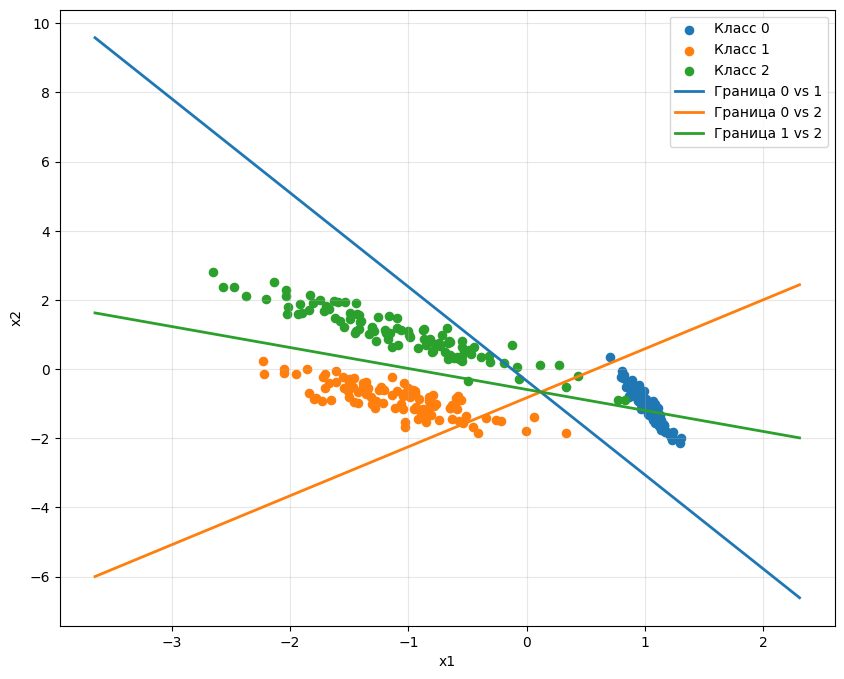

In [6]:
plt.figure(figsize=(10, 8))

for cls in range(M):
    plt.scatter(X_raw[y == cls, 0], X_raw[y == cls, 1], s=35, label=f"Класс {cls}")

x1_vals = np.linspace(X_raw[:, 0].min() - 1, X_raw[:, 0].max() + 1, 400)

for j in range(M):
    for k in range(j + 1, M):
        w_diff = W[:, j] - W[:, k]
        if abs(w_diff[2]) < 1e-9:
            continue
        x2_vals = -(w_diff[0] + w_diff[1] * x1_vals) / w_diff[2]
        plt.plot(x1_vals, x2_vals, linewidth=2, label=f"Граница {j} vs {k}")

plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## Как происходит классификация и что такое границы (гиперплоскости)

После обучения вычисляем скоры $z_{ij}=\omega_j^\top x_i$ и вероятности $p_{ij}$ через softmax.
Класс выбираем по правилу:
$$
\hat y_i = \arg\max_{j} p_{ij} = \arg\max_{j} z_{ij}.
$$

Граница между двумя классами $j$ и $k$ задаётся равенством их скоров:
$$
\omega_j^\top x = \omega_k^\top x
\;\Longleftrightarrow\;
(\omega_j-\omega_k)^\top x = 0.
$$
Это гиперплоскость (в 2D — прямая), которую и можно изобразить на синтетических данных.
